**Autor**: Juan Alejandro Carrillo Jaimes

**Creación**: 10-08-2026

**Ult Modificación**: 10-08-2026

**Materia**: Mét. Apren Auto para Toma de Decisiones 20262  - A

**Descripción**: Script de entrenamiento de un clasificador de regresión
logística sobre el dataset Wine Quality (UCI), comparando el desempeño
(accuracy) obtenido bajo distintas versiones del conjunto de datos,
construidas progresivamente a partir de las actividades de preparación
de datos (tratamiento de datos faltantes, atípicos, atributos
correlacionados y balanceo de clases).

**Nota:** las actividades de entendimiento y preparación de los datos
(identificación de tipos de atributo, medidas de centralidad y dispersión,
matriz de correlación, balanceo, datos faltantes y atípicos) fueron
desarrolladas previamente en el notebook de la actividad de Acción,
disponible en:
https://colab.research.google.com/drive/1tL9i-txPhwZkFBPkto_hxkidzr_lQVKo?usp=sharing

En este notebook se retoman esos hallazgos y criterios para construir,
de forma progresiva, las distintas versiones del conjunto de datos
solicitadas en esta actividad.

## Descripción de la actividad

En este notebook se entrena un **clasificador de regresión logística**
con el objetivo de predecir la calidad de un vino (`quality`) a partir de
sus atributos fisicoquímicos, evaluando cómo cambia el desempeño del
modelo (medido con **accuracy**) según el nivel de preparación aplicado
al conjunto de datos.

Se construyen 6 versiones progresivas del dataset:

1. Conjunto original (transformando datos categóricos, si aplica).
2. Conjunto sin datos faltantes.
3. Conjunto sin datos faltantes ni atípicos.
4. Conjunto sin datos faltantes, atípicos, ni atributos correlacionados.
5. Conjunto del paso 4, balanceado.
6. Conjunto del paso 5, aplicando PCA.

Para cada versión se entrena un modelo de regresión logística y se
reporta su accuracy sobre un conjunto de prueba, con el fin de identificar
qué actividades de preparación tienen mayor impacto en el desempeño del
modelo.

In [1]:
!pip install ucimlrepo -q \
             pyod -q \
             imbalanced-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 414.5/414.5 kB 6.8 MB/s eta 0:00:00


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from pyod.models.iforest import IForest
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

### **Carga del conjunto de datos**

Obtener el dataset directamente desde UCI y dejarlo disponible como dataframes de pandas, listos para trabajar.

In [3]:
# Se descarga el dataset Wine Quality (id=186) desde el repositorio UCI
wine_quality = fetch_ucirepo(id=186)

# Datos en formato de dataframes de pandas
X = wine_quality.data.features   # atributos de entrada
y = wine_quality.data.targets    # atributo objetivo (quality)

# Se consolida un único dataframe para facilitar el análisis exploratorio
data = pd.concat([X, y], axis=1)

In [4]:
# Metadatos generales del dataset (solo los campos relevantes)
meta = wine_quality.metadata

print(f"Nombre del dataset : {meta['name']}")
print(f"N° de instancias   : {meta['num_instances']}")
print(f"N° de atributos    : {meta['num_features']}")
print(f"¿Datos faltantes?  : {meta['has_missing_values']}")
print(f"Tareas asociadas   : {', '.join(meta['tasks'])}")
print(f"URL del repositorio: {meta['repository_url']}")

Nombre del dataset : Wine Quality
N° de instancias   : 4898
N° de atributos    : 11
¿Datos faltantes?  : no
Tareas asociadas   : Classification, Regression
URL del repositorio: https://archive.ics.uci.edu/dataset/186/wine+quality


In [6]:
# Información de las variables
variables_info = wine_quality.variables.dropna(axis=1, how='all')
print(f"Dimensiones: {data.shape}")
variables_info

Dimensiones: (6497, 12)


,name,role,type,description,missing_values
0,fixed_acidity,Feature,Continuous,None,no
1,volatile_acidity,Feature,Continuous,None,no
2,citric_acid,Feature,Continuous,None,no
3,residual_sugar,Feature,Continuous,None,no
4,chlorides,Feature,Continuous,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,no
7,density,Feature,Continuous,None,no
8,pH,Feature,Continuous,None,no
9,sulphates,Feature,Continuous,None,no


In [7]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Etapa 1: Entendimiento - Conocimiento de los datos

En esta etapa se realizan actividades que permiten conocer las características
del conjunto de datos **sin modificarlo**, con el fin de identificar
situaciones que puedan afectar negativamente el proceso de aprendizaje
(datos faltantes, atípicos, desbalanceo, correlación entre variables, etc.).

### 1.1 Número de muestras y atributos, y tipo de cada atributo

Antes, una aclaración importante sobre color: como tiene `role = "Other"`, la librería `ucimlrepo` **no lo incluye** ni en `X` (que solo trae role=Feature) ni en y (que solo trae role=Target). Por eso, el dataframe **data** actual solo tiene 12 columnas (11 features + quality), sin `color`.

In [16]:
color = wine_quality.data.original['color']
data['color'] = color

# Dimensiones del dataset
n_muestras, n_atributos = data.shape
print(f"Número de muestras : {n_muestras}")
print(f"Número de atributos: {n_atributos - 1}") # sin contar atributo quality

Número de muestras : 6497
Número de atributos: 12


In [17]:
# Tipo de dato de cada atributo (tal como lo interpreta pandas)
tipos = pd.DataFrame({
    'tipo_pandas': data.dtypes,
    'tipo_conceptual': [
        'Categórico (nominal)' if data[col].dtype == 'object'
        else 'Discreto (entero)' if pd.api.types.is_integer_dtype(data[col])
        else 'Continuo'
        for col in data.columns
    ]
})
tipos

,tipo_pandas,tipo_conceptual
fixed_acidity,float64,Continuo
volatile_acidity,float64,Continuo
citric_acid,float64,Continuo
residual_sugar,float64,Continuo
chlorides,float64,Continuo
free_sulfur_dioxide,float64,Continuo
total_sulfur_dioxide,float64,Continuo
density,float64,Continuo
pH,float64,Continuo
sulphates,float64,Continuo


In [18]:
# valores faltantes
print("Total de valores faltantes...\n")
print(data.isnull().sum())

Total de valores faltantes...

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64


In [19]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### 1.2 Medidas de centralidad y dispersión por atributo

- Atributos continuos `describe() (media, std, quartiles)`
- `quality` (discreto/ordinal) y `color` (categórico) conteos + gráficos de barras.

In [20]:
atributos_continuos = [col for col in data.columns
                       if data[col].dtype == 'float64']
# Medidas de centralidad y dispersión
data[atributos_continuos].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


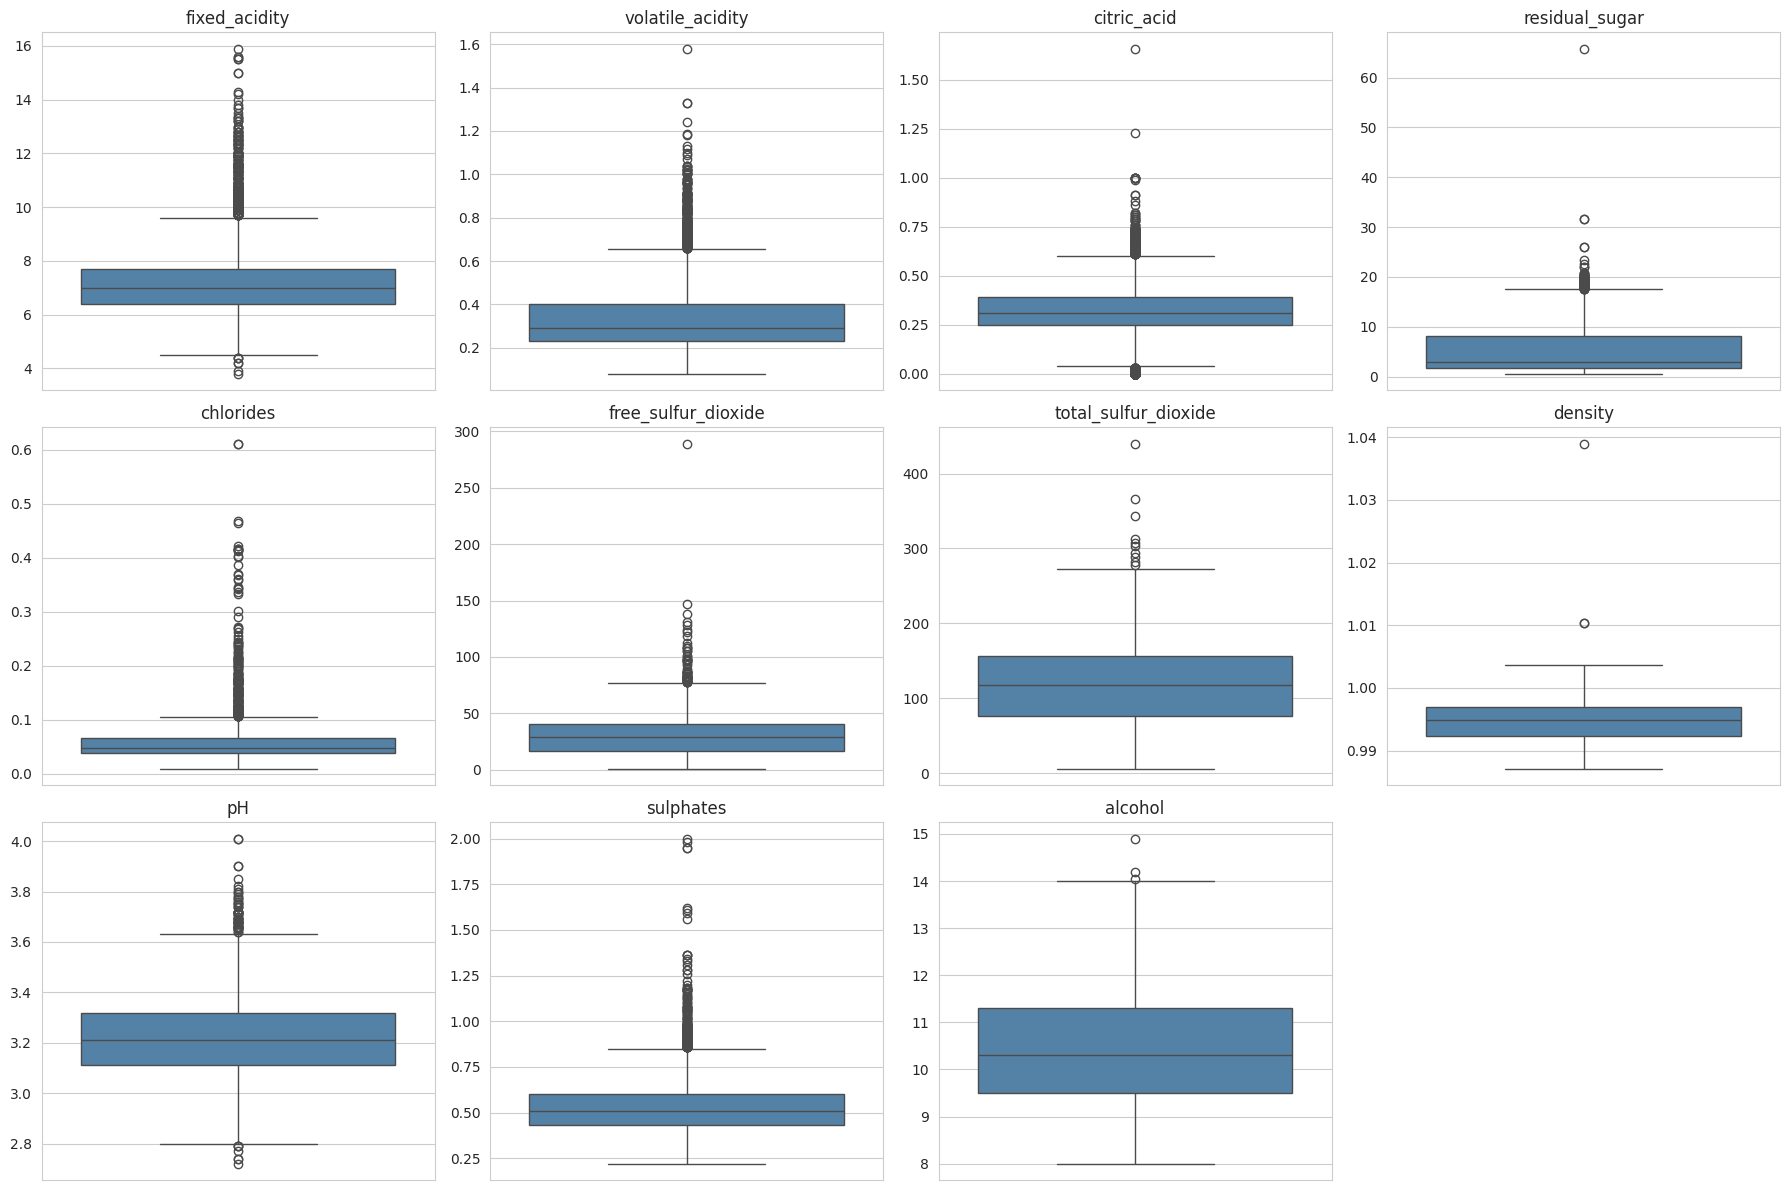

In [21]:
# Boxplots de los atributos continuos
# Se separan en dos figuras por escalas muy distintas
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.boxplot(y=data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# Se ocultan los ejes sobrantes (12 subplots, 11 atributos)
for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Casi todos los atributos presentan numerosos outliers hacia arriba, un
comportamiento típico de variables fisicoquímicas con distribución sesgada
a la derecha (asimetría positiva): la mayoría de los vinos tiene valores
bajos o moderados y relativamente similares entre sí, mientras que un grupo
minoritario presenta valores considerablemente más altos, que se alejan del
resto y aparecen como outliers en el gráfico.

Este comportamiento se observa principalmente en: `residual_sugar`,
`chlorides`, `free_sulfur_dioxide`, `total_sulfur_dioxide`, `sulphates` y
`citric_acid`, los cuales muestran nubes densas de círculos por encima del
bigote superior.

count    6497.000000
mean        5.818378
std         0.873255
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

Conteo por valor de calidad:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


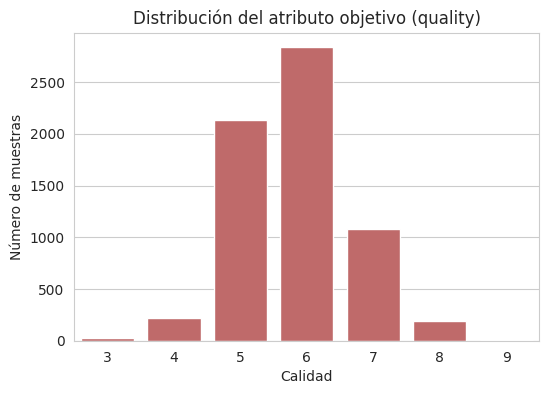

In [22]:
# Medidas de centralidad/dispersión y distribución de 'quality'
print(data['quality'].describe())
print("\nConteo por valor de calidad:")
print(data['quality'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=data, color='indianred')
plt.title('Distribución del atributo objetivo (quality)')
plt.xlabel('Calidad')
plt.ylabel('Número de muestras')
plt.show()

In [23]:
# Conteo y porcentaje por valor de quality, en formato horizontal
conteo = data['quality'].value_counts().sort_index()
porcentaje = (data['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

resumen_quality = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje
}).T

resumen_quality

quality,3,4,5,6,7,8,9
Conteo,30.00,216.00,2138.00,2836.00,1079.00,193.00,5.00
Porcentaje (%),0.46,3.32,32.91,43.65,16.61,2.97,0.08


Se observa que la media está en `5.81` y la mediana en `6.0` están muy cerca. Esto es bueno, indica que la calidad (quality) no está muy sesgada.  Así que está ligeramente simétrica. Siin embargo, hay un problema de desbalanceo de clases. En la gráfica anterior se ve como las clases 5 y 6 concentran el `76.56` de los datos. Y el resto de muestras por fuera de estos, apenas tienen unos pocos ejemplares. Este problema supone una oportunidad para aplicar una técnica de balanceo de clases como `undersampling`, `oversampling` o reagrupaciín de clases en categorías diferentes.

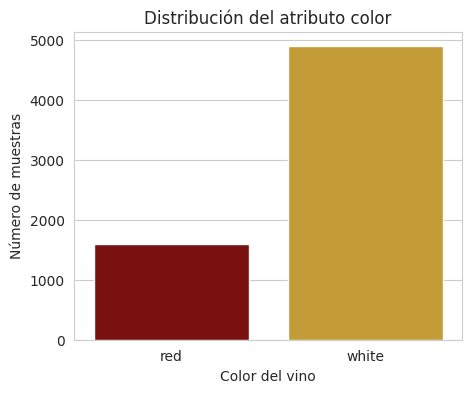

color,red,white
Conteo,1599.00,4898.00
Porcentaje (%),24.61,75.39


In [24]:
# Distribución del atributo 'color'
conteo = data['color'].value_counts().sort_index()
porcentaje = (data['color'].value_counts(normalize=True).sort_index() * 100).round(2)

resumen_color = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje
}).T



plt.figure(figsize=(5, 4))
sns.countplot(x='color', hue='color', data=data, palette={'red': '#8B0000', 'white': '#DAA520'}, legend=False)
plt.title('Distribución del atributo color')
plt.xlabel('Color del vino')
plt.ylabel('Número de muestras')
plt.show()

resumen_color

El atributo `color` también presenta desbalance: el 75.39% de las muestras
corresponde a vino blanco (4898) y el 24.61% a vino tinto (1599), una
proporción aproximada de 3 a 1. Esta mezcla desigual puede explicar, el sesgo y los outliers observados en algunos atributos
fisicoquímicos (como `residual_sugar`), ya que tinto y blanco suelen tener
perfiles distintos.

#### 1.2.1 Verificación del sesgo: boxplots separados por color

Para confirmar si el sesgo y los outliers observados en algunos atributos
(como `residual_sugar`) se deben a la mezcla de vinos tinto y blanco, se
grafican los boxplots de los atributos continuos separados por el atributo
`color`.

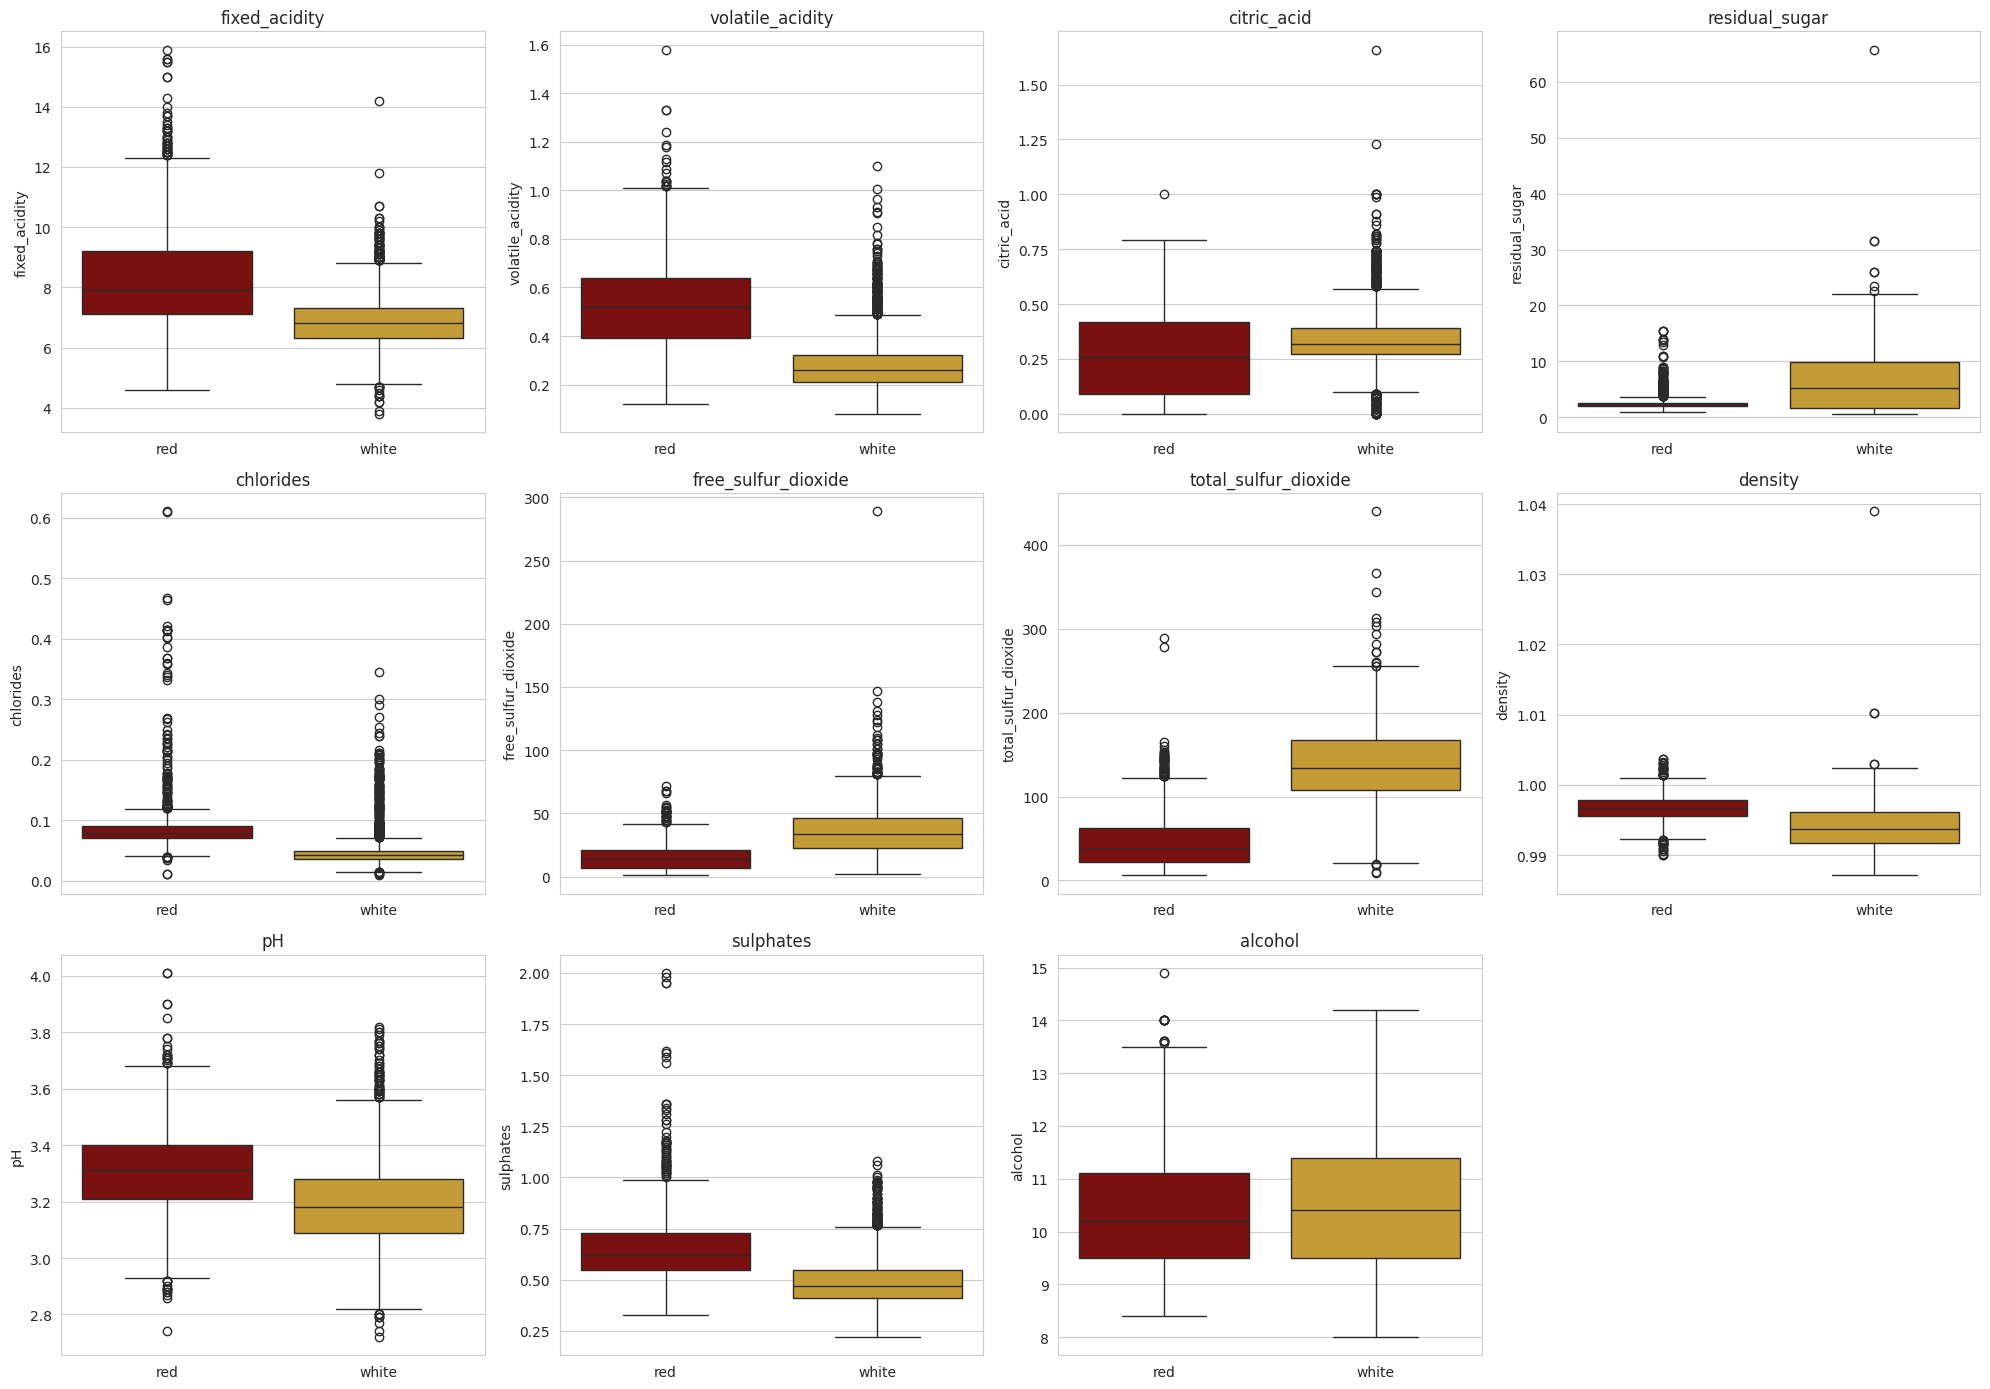

In [25]:
# Boxplots de los atributos continuos, separados por color
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.boxplot(x='color', y=col, data=data, ax=axes[i],
                hue='color', palette={'red': '#8B0000', 'white': '#DAA520'}, legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Se ocultan los ejes sobrantes
for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

El color del vino explica parcialmente el sesgo observado
en variables como `residual_sugar`, `free_sulfur_dioxide` y
`total_sulfur_dioxide`, donde tinto y blanco muestran medianas claramente
distintas. Sin embargo, en atributos como `chlorides`, `volatile_acidity`,
`sulphates` y `fixed_acidity`, el sesgo y los outliers persisten dentro de
cada grupo por separado, lo que indica que se trata de una característica
propia de la variable (y no solo un efecto de mezclar tinto y blanco). Esto supone, que los valores atípicos deben analizarse y tratarse con cuidado.

### 1.3 Matriz de correlación entre los atributos de entrada

Se calcula la correlación (Pearson) entre los 11 atributos fisicoquímicos
de entrada, para identificar relaciones lineales fuertes entre ellos
(redundancia de información) que puedan ser relevantes para la etapa de
**preparación de datos**.

In [26]:
# Matriz de correlación de Pearson entre los atributos de entrada
matriz_corr = data[atributos_continuos].corr()
matriz_corr

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
fixed_acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452
volatile_acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640
citric_acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493
residual_sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916
free_sulfur_dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838
total_sulfur_dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029


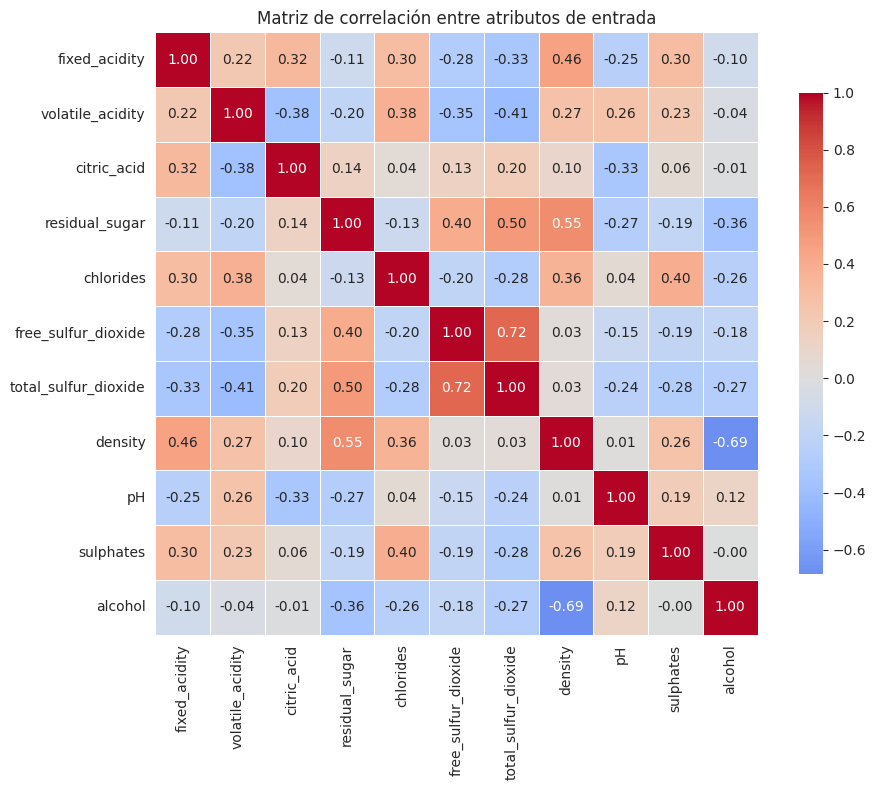

In [27]:
# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación entre atributos de entrada')
plt.tight_layout()
plt.show()

In [28]:
# Se listan los pares de atributos con mayor correlación (positiva o negativa),
# excluyendo la diagonal (correlación de un atributo consigo mismo)
corr_pairs = matriz_corr.where(
    ~np.eye(matriz_corr.shape[0], dtype=bool)
).unstack().dropna()

corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
corr_pairs.sort_values(key=abs, ascending=False).head(10)

,,0
free_sulfur_dioxide,total_sulfur_dioxide,0.720934
alcohol,density,-0.686745
density,residual_sugar,0.552517
residual_sugar,total_sulfur_dioxide,0.495482
density,fixed_acidity,0.458910
total_sulfur_dioxide,volatile_acidity,-0.414476
free_sulfur_dioxide,residual_sugar,0.402871
chlorides,sulphates,0.395593
citric_acid,volatile_acidity,-0.377981
chlorides,volatile_acidity,0.377124


In [29]:
# Dataframe con las variables que presentan alta correlación entre sí
columnas_alta_corr = ['alcohol', 'density', 'free_sulfur_dioxide',
                      'total_sulfur_dioxide']

data_corr_alta = data[columnas_alta_corr]
data_corr_alta.head()

,alcohol,density,free_sulfur_dioxide,total_sulfur_dioxide
0,9.4,0.9978,11.0,34.0
1,9.8,0.9968,25.0,67.0
2,9.8,0.9970,15.0,54.0
3,9.8,0.9980,17.0,60.0
4,9.4,0.9978,11.0,34.0


Ningún par de atributos supera |r| = 0.75, por lo que **no hay evidencia de
multicolinealidad extrema** que obligue a _eliminar variables en esta etapa_.

Sin embargo, sí se identifican varios pares con correlación moderada-alta
(`free_sulfur_dioxide`-`total_sulfur_dioxide`: 0.72, `alcohol`-`density`:
-0.69, `density`-`residual_sugar`: 0.55), lo que indica cierto grado de
redundancia de información entre los 11 atributos originales.

Por ahora, **no se elimina ningún atributo en la etapa de preparación**
únicamente por motivo de correlación; la decisión se dejará para una
eventual etapa de selección de características, en función del modelo
que se use.

### 1.4 Datos faltantes por clase

Se verifica la presencia de valores faltantes en el dataset, tanto de forma
global como desglosada por cada valor del atributo objetivo (`quality`).

In [30]:
# Conteo de valores faltantes por atributo (global)
faltantes = data.isnull().sum()
faltantes_pct = (data.isnull().mean() * 100).round(2)

resumen_faltantes = pd.DataFrame({
    'faltantes': faltantes,
    'porcentaje (%)': faltantes_pct
})
resumen_faltantes

,faltantes,porcentaje (%)
fixed_acidity,0,0.0
volatile_acidity,0,0.0
citric_acid,0,0.0
residual_sugar,0,0.0
chlorides,0,0.0
free_sulfur_dioxide,0,0.0
total_sulfur_dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [31]:
# Conteo de valores faltantes por atributo, desglosado por clase (quality)
faltantes_por_clase = data.set_index('quality').isnull().groupby(level=0).sum()
faltantes_por_clase

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color
quality,,,,,,,,,,,,
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0


El dataset **no presenta valores faltantes en ningún atributo**, ni de forma global ni al desglosar por clase de `quality`.No será necesario aplicar técnicas de imputación en la etapa de
preparación de datos.

### 1.5 Identificación de datos atípicos por clase

Se utiliza la librería `pyod` (Python Outlier Detection) para identificar
observaciones atípicas de forma multivariada (considerando simultáneamente
los 11 atributos fisicoquímicos), a diferencia de los boxplots anteriores
que evaluaban cada atributo por separado. Se aplica el algoritmo
**Isolation Forest**, y se reporta el número de atípicos detectados por
cada clase del atributo objetivo (`quality`).

In [32]:
from pyod.models.iforest import IForest

In [33]:
# Se estandarizan los atributos continuos antes de aplicar el detector
# (Isolation Forest no lo exige estrictamente, pero ayuda a que todas las
# variables aporten en igualdad de condiciones)
from sklearn.preprocessing import StandardScaler

X_continuas = data[atributos_continuos]
X_scaled = StandardScaler().fit_transform(X_continuas)
X_scaled

array([[ 0.14247327,  2.18883292, -2.19283252, ...,  1.81308951,
         0.19309677, -0.91546416],
       [ 0.45103572,  3.28223494, -2.19283252, ..., -0.11507303,
         0.99957862, -0.58006813],
       [ 0.45103572,  2.55330026, -1.91755268, ...,  0.25811972,
         0.79795816, -0.58006813],
       ...,
       [-0.55179227, -0.6054167 , -0.88525328, ..., -1.42124765,
        -0.47897144, -0.91546416],
       [-1.32319841, -0.30169391, -0.12823371, ...,  0.75571005,
        -1.016626  ,  1.9354021 ],
       [-0.93749534, -0.78765037,  0.42232597, ...,  0.25811972,
        -1.41986693,  1.09691202]])

In [34]:
detector = IForest(contamination=0.1, random_state=42)
detector.fit(X_scaled)

IForest(behaviour='old', bootstrap=False, contamination=0.1, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=42,
    verbose=0)

In [35]:
# 0 = normal, 1 = atípico
data['es_atipico'] = detector.labels_
print(f"Total de datos atípicos detectados: {data['es_atipico'].sum()} de {len(data)}")

Total de datos atípicos detectados: 650 de 6497


In [36]:
# Número de datos atípicos por clase (quality)
atipicos_por_clase = data.groupby('quality')['es_atipico'].agg(
    total_muestras='count',
    n_atipicos='sum'
)
atipicos_por_clase['porcentaje (%)'] = (
    atipicos_por_clase['n_atipicos'] / atipicos_por_clase['total_muestras'] * 100
).round(2)

atipicos_por_clase

,total_muestras,n_atipicos,porcentaje (%)
quality,,,
3,30,18,60.00
4,216,34,15.74
5,2138,243,11.37
6,2836,249,8.78
7,1079,89,8.25
8,193,17,8.81
9,5,0,0.00


#### 1.5.1 Exploración detallada de las clases minoritarias (quality 3 y 4)

In [37]:
# Se seleccionan las muestras de quality 3 y quality 4 por separado
data_q3 = data[data['quality'] == 3]
data_q4 = data[data['quality'] == 4]

In [38]:
print("Quality = 3")
data_q3[atributos_continuos].describe()

Quality = 3


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,30.000000,30.000000,30.00000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,7.853333,0.517000,0.28100,5.140000,0.077033,39.216667,122.033333,0.995744,3.257667,0.506333,10.215000
std,1.747853,0.341913,0.17351,4.730721,0.062014,59.990327,112.141762,0.002833,0.213246,0.126994,1.106497
min,4.200000,0.170000,0.00000,0.700000,0.022000,3.000000,9.000000,0.991100,2.870000,0.280000,8.000000
25%,6.800000,0.252500,0.21250,1.650000,0.038750,5.250000,30.000000,0.993750,3.140000,0.407500,9.625000
50%,7.450000,0.415000,0.33000,3.150000,0.055000,17.000000,102.500000,0.995900,3.245000,0.505000,10.150000
75%,8.575000,0.632500,0.39500,7.800000,0.081000,37.375000,193.250000,0.998060,3.415000,0.565000,11.000000
max,11.800000,1.580000,0.66000,16.200000,0.267000,289.000000,440.000000,1.000800,3.630000,0.860000,12.600000


In [39]:
print("\nQuality = 4")
data_q4[atributos_continuos].describe()


Quality = 4


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.00000,216.000000,216.000000
mean,7.288889,0.457963,0.272315,4.153704,0.060056,20.636574,103.432870,0.994833,3.23162,0.505648,10.180093
std,1.264825,0.229311,0.182079,3.812136,0.047068,18.865524,61.282714,0.002475,0.18839,0.164434,0.985923
min,4.600000,0.110000,0.000000,0.700000,0.013000,3.000000,7.000000,0.989200,2.74000,0.250000,8.400000
25%,6.400000,0.280000,0.140000,1.400000,0.040750,8.000000,55.000000,0.993030,3.09000,0.400000,9.400000
50%,7.000000,0.380000,0.260000,2.200000,0.050500,15.000000,102.000000,0.994995,3.22000,0.485000,10.000000
75%,8.000000,0.610000,0.372500,5.600000,0.067000,27.250000,151.000000,0.996655,3.35000,0.570000,10.900000
max,12.500000,1.130000,1.000000,17.550000,0.610000,138.500000,272.000000,1.001000,3.90000,2.000000,13.500000


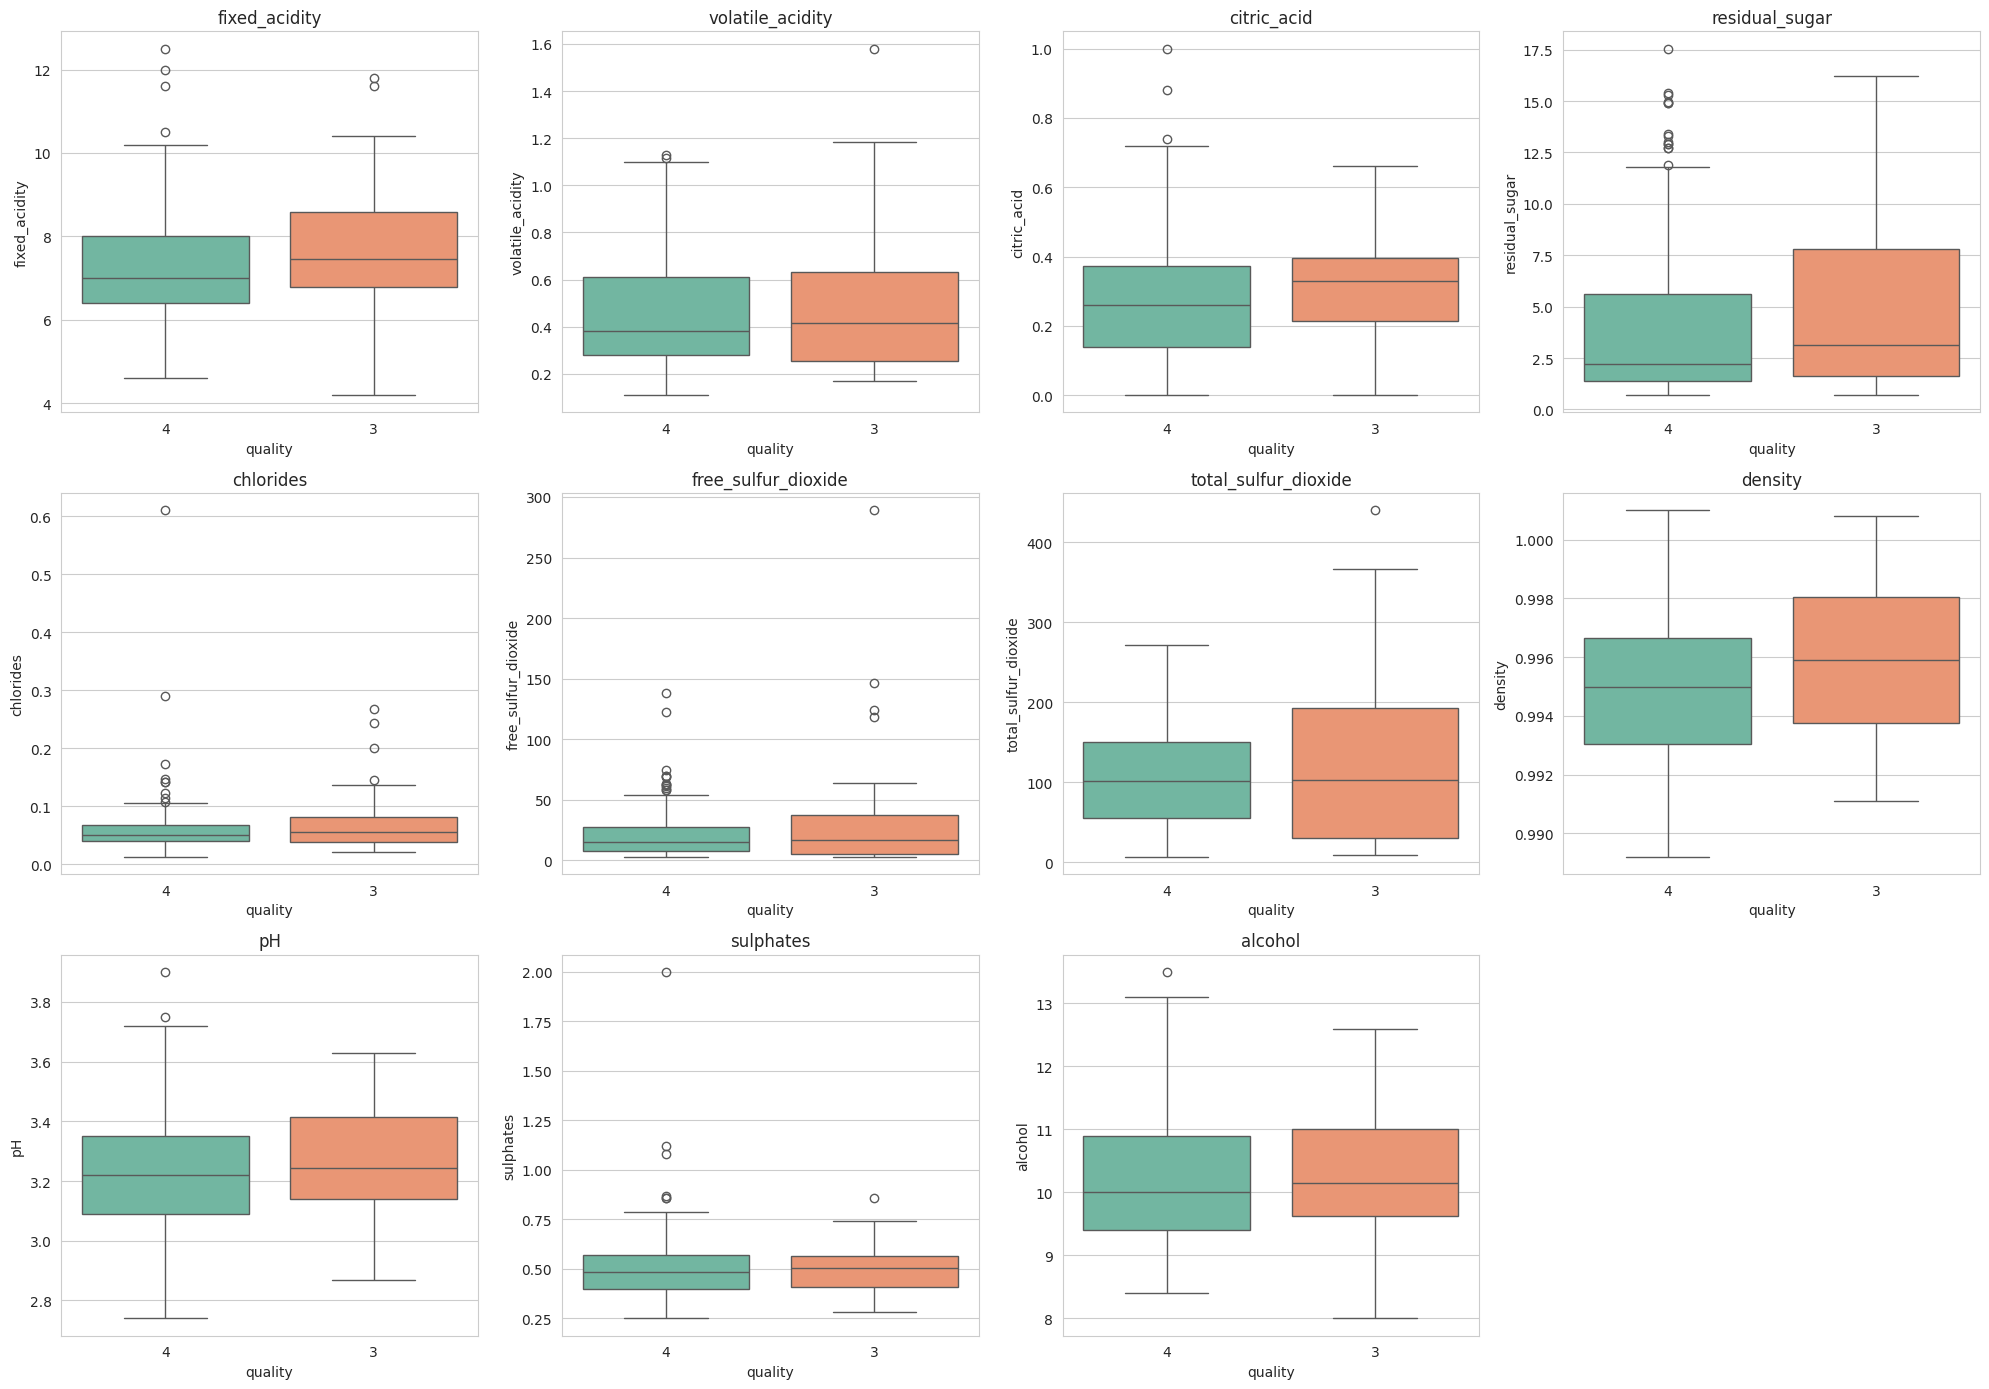

In [40]:
# Subconjunto combinado (solo quality 3 y 4), para comparar lado a lado
data_q3_q4 = data[data['quality'].isin([3, 4])].copy()
data_q3_q4['quality'] = data_q3_q4['quality'].astype(str)  # para que se trate como categoría

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.boxplot(x='quality', y=col, data=data_q3_q4, ax=axes[i],
                hue='quality', palette='Set2', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('quality')

for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

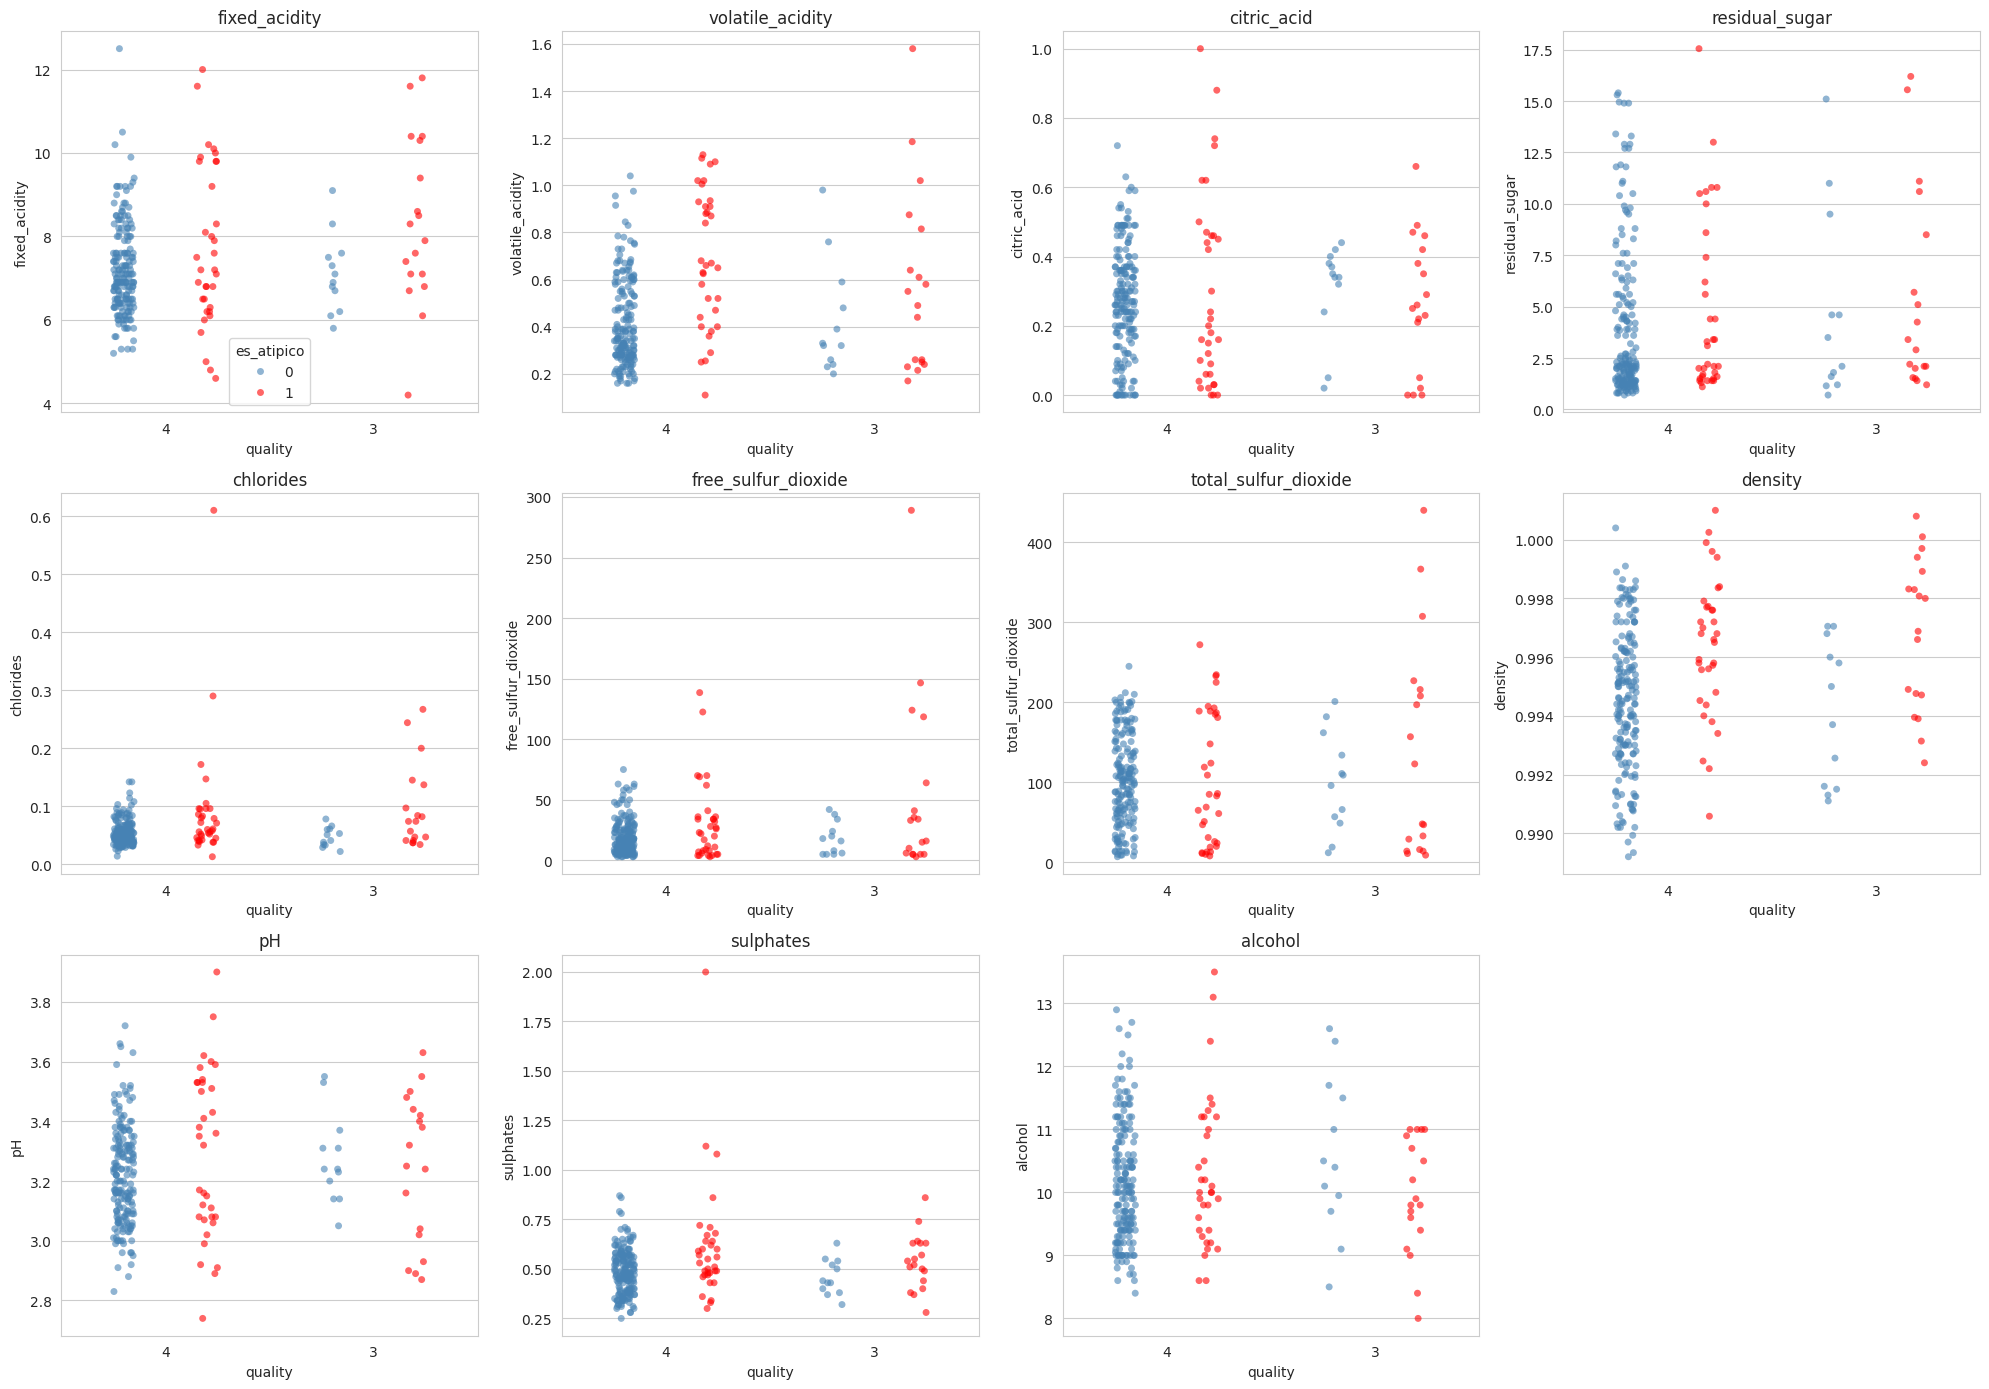

In [41]:
# Igual al anterior, pero coloreando los puntos según si fueron marcados como atípicos
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.stripplot(x='quality', y=col, data=data_q3_q4, ax=axes[i],
                  hue='es_atipico', palette={0: 'steelblue', 1: 'red'},
                  dodge=True, alpha=0.6, legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('quality')

for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Conclusión:** al desagregar visualmente los datos atípicos dentro de las
clases 3 y 4, se observa que estos NO se distribuyen al azar dentro de cada
clase, sino que presentan un perfil fisicoquímico sistemáticamente distinto:
mayor `volatile_acidity`, mayor `density`, mayor `pH` y menor `alcohol`
respecto a las muestras "normales" de la misma clase.

Esto sugiere que, dentro de las clases minoritarias, el detector no está
simplemente marcando "ruido aleatorio", sino identificando un subperfil
químico específico (posiblemente vinos con defectos de fermentación o
elaboración, dada la asociación conocida entre alta acidez volátil y
defectos del vino). Esto refuerza la recomendación de NO eliminar estos
atípicos sin un análisis más profundo, ya que podrían representar
información real y relevante para distinguir vinos de baja calidad, más
que errores de captura de datos.

### 1.6 Conclusión general — Etapa 1: Entendimiento de los datos

El dataset tiene 6497 muestras, 11 atributos continuos de entrada, el
atributo objetivo `quality` (discreto, 3-9) y el atributo `color`
(categórico). No presenta datos faltantes.

Los hallazgos más relevantes para la etapa de preparación son:

- **Desbalanceo fuerte en `quality`**: las clases 5 y 6 concentran ~77%
  de los datos; las clases extremas (3 y 9) son casi inexistentes.
- **Atípicos concentrados en las clases minoritarias**: de los 650
  atípicos detectados con `IForest` (10%), el porcentaje sube hasta 60%
  en `quality=3`, frente a ~8-11% en las clases mayoritarias. Esto está
  ligado al desbalanceo, no son errores de medición.
- **Sin multicolinealidad extrema** entre atributos de entrada (máx.
  |r|=0.72), por lo que no se elimina ningún atributo por esta razón.

En consecuencia, en la Etapa 2 se trabajará principalmente el **balanceo
de clases** y **no se eliminarán los atípicos de forma automática**, ya
que agravaría el desbalanceo. Además, se codificará `color` y se
escalarán los atributos continuos.

## Etapa 2: Preparación de los datos y entrenamiento del modelo

Se construyen 6 versiones progresivas del conjunto de datos, entrenando
en cada una un clasificador de regresión logística sobre el atributo
objetivo `quality` (7 clases, 3-9). Se define primero una función
reutilizable para entrenar y evaluar el modelo, y luego se construye cada
caso de forma acumulativa.

1. Conjunto original (transformando datos categóricos, si aplica).
2. Conjunto sin datos faltantes.
3. Conjunto sin datos faltantes ni atípicos.
4. Conjunto sin datos faltantes, atípicos, ni atributos correlacionados.
5. Conjunto del paso 4, balanceado.
6. Conjunto del paso 5, aplicando PCA.

### Función de entrenamiento y evaluación

Se define una función que recibe los atributos de entrada (`X`) y el
objetivo (`y`), divide en entrenamiento/prueba, entrena un modelo de
regresión logística y devuelve el accuracy obtenido, para reutilizarla
en cada uno de los 6 casos.

In [42]:
# Diccionario donde se guardarán los resultados de cada caso
resultados = {}

def entrenar_y_evaluar(X, y, nombre_caso, test_size=0.2, random_state=42):
    """
    Divide en train/test, entrena un modelo de regresión logística
    y calcula el accuracy sobre el conjunto de prueba.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(max_iter=1000, random_state=random_state)
    modelo.fit(X_train, y_train)

    predicciones = modelo.predict(X_test)
    acc = accuracy_score(y_test, predicciones)

    resultados[nombre_caso] = acc
    print(f"[{nombre_caso}] Accuracy: {acc:.4f}  |  n_muestras: {len(X)}  |  n_atributos: {X.shape[1]}")
    return acc

### Función de escalado

Se define una función auxiliar para aplicar `StandardScaler` a los
atributos continuos de cualquier versión del dataset, reutilizándola en
los 6 casos.

In [45]:
def escalar_continuos(df, columnas=atributos_continuos):
    """
    Aplica StandardScaler a las columnas continuas indicadas,
    devolviendo una copia del dataframe con esas columnas escaladas.
    """
    df_escalado = df.copy()
    df_escalado[columnas] = StandardScaler().fit_transform(df_escalado[columnas])
    return df_escalado

### Caso 1: Conjunto original (transformando datos categóricos)

Se parte del dataset original, sin eliminar datos faltantes, atípicos ni
atributos correlacionados, y sin balancear. Solo se codifica el atributo
categórico `color`, ya que la regresión logística requiere entradas
numéricas.

In [46]:
# Caso 1: dataset original, con 'color' codificado y atributos continuos escalados
data_caso1 = data.drop(columns=['es_atipico']).copy()
data_caso1['color'] = data_caso1['color'].map({'red': 0, 'white': 1})
data_caso1 = escalar_continuos(data_caso1)

X_caso1 = data_caso1.drop(columns=['quality'])
y_caso1 = data_caso1['quality']

entrenar_y_evaluar(X_caso1, y_caso1, 'Caso 1: Original')

[Caso 1: Original] Accuracy: 0.5408  |  n_muestras: 6497  |  n_atributos: 12


0.5407692307692308

### Caso 2: Conjunto sin datos faltantes

Como se determinó en la Etapa 1, el dataset no presenta valores faltantes
en ningún atributo. Por lo tanto, este caso es equivalente al Caso 1: no
hay filas ni valores que eliminar o imputar.

In [47]:
# Caso 2: sin datos faltantes (no aplica ningún cambio, ya que no existen)
data_caso2 = data_caso1.copy()

X_caso2 = data_caso2.drop(columns=['quality'])
y_caso2 = data_caso2['quality']

entrenar_y_evaluar(X_caso2, y_caso2, 'Caso 2: Sin faltantes')

[Caso 2: Sin faltantes] Accuracy: 0.5408  |  n_muestras: 6497  |  n_atributos: 12


0.5407692307692308

### Caso 3: Conjunto sin datos faltantes ni atípicos

Se eliminan las 650 muestras marcadas como atípicas por `IForest` en la
Etapa 1 (10% del dataset), partiendo del Caso 2.

In [48]:
# Caso 3: se eliminan los registros marcados como atípicos (es_atipico == 1)
data_caso3 = data.drop(columns=[]).copy()  # partimos de 'data', que aún tiene 'es_atipico'
data_caso3 = data_caso3[data_caso3['es_atipico'] == 0].drop(columns=['es_atipico'])
data_caso3['color'] = data_caso3['color'].map({'red': 0, 'white': 1})
data_caso3 = escalar_continuos(data_caso3)

X_caso3 = data_caso3.drop(columns=['quality'])
y_caso3 = data_caso3['quality']

entrenar_y_evaluar(X_caso3, y_caso3, 'Caso 3: Sin faltantes ni atípicos')

[Caso 3: Sin faltantes ni atípicos] Accuracy: 0.5573  |  n_muestras: 5847  |  n_atributos: 12


0.5572649572649573

**Conclusión:** al eliminar los **650** datos atípicos, el accuracy mejora de
**0.5408 a 0.5573**. Sin embargo, esta mejora debe interpretarse con cautela:
como se identificó en la Etapa 1, los atípicos se concentraban
desproporcionadamente en las clases minoritarias (`quality=3` y 4), por lo
que este caso reduce aún más su representación en el dataset (de 6497 a
5847 muestras), lo que podría estar sesgando el modelo aún más hacia las
clases mayoritarias en lugar de reflejar una mejora real en la calidad
de los datos.

### Caso 4: Conjunto sin datos faltantes, atípicos ni atributos correlacionados

Partiendo del Caso 3, se eliminan los atributos redundantes según los
pares más correlacionados identificados en la Etapa 1:
- `free_sulfur_dioxide` (correlación 0.72 con `total_sulfur_dioxide`) → se
  conserva `total_sulfur_dioxide`, que incluye la información del libre.
- `density` (correlación -0.69 con `alcohol`) → se conserva `alcohol`,
  más interpretable y de relación más directa con la calidad del vino.

In [49]:
# Caso 4: se eliminan atributos correlacionados, partiendo del Caso 3
atributos_a_eliminar = ['free_sulfur_dioxide', 'density']
atributos_continuos_reducidos = [a for a in atributos_continuos if a not in atributos_a_eliminar]

data_caso4 = data[data['es_atipico'] == 0].drop(columns=['es_atipico']).copy()
data_caso4 = data_caso4.drop(columns=atributos_a_eliminar)
data_caso4['color'] = data_caso4['color'].map({'red': 0, 'white': 1})
data_caso4 = escalar_continuos(data_caso4, columnas=atributos_continuos_reducidos)

X_caso4 = data_caso4.drop(columns=['quality'])
y_caso4 = data_caso4['quality']

entrenar_y_evaluar(X_caso4, y_caso4, 'Caso 4: + Sin correlacionados')

[Caso 4: + Sin correlacionados] Accuracy: 0.5538  |  n_muestras: 5847  |  n_atributos: 10


0.5538461538461539

**Conclusión:** al eliminar los dos atributos correlacionados
(`free_sulfur_dioxide` y `density`), el accuracy baja levemente de 0.5573
a 0.5538. Esto es coherente con lo observado en la Etapa 1: como ningún
par de atributos superaba **|r|=0.75**, la redundancia entre ellos no era
extrema, por lo que cada atributo eliminado seguía aportando algo de
información útil al modelo (aunque parcialmente compartida con su par
correlacionado). El costo de eliminarlos (leve pérdida de accuracy) es
menor al beneficio potencial de reducir dimensionalidad, lo cual confirma
que en este dataset la correlación no era un problema urgente de resolver,
tal como se concluyó en la Etapa 1.

### Caso 5: Conjunto balanceado

Partiendo del Caso 4, las clases de `quality` están muy desbalanceadas
(desde 5 muestras en `quality=9` hasta 2587 en `quality=6`). Se balancean
llevando todas las clases a un tamaño intermedio (1500), combinando
`RandomUnderSampler` en las clases mayoritarias (5 y 6) con `SMOTE` en las
minoritarias (3, 4, 7, 8, 9).

**Ajuste técnico:** `SMOTE` genera muestras sintéticas interpolando entre
los *k* vecinos más cercanos dentro de la misma clase. Como `quality=9`
tiene solo 5 muestras, se reduce `k_neighbors` de 5 (valor por defecto) a
4, el máximo posible dado ese tamaño de clase.

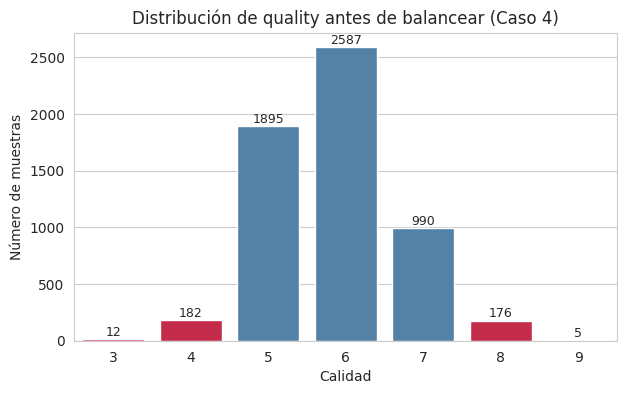

In [51]:
conteo_caso4 = y_caso4.value_counts().sort_index()

plt.figure(figsize=(7, 4))
colores = ['crimson' if n < 200 else 'steelblue' for n in conteo_caso4]
sns.barplot(x=conteo_caso4.index, y=conteo_caso4.values, hue=conteo_caso4.index,
            palette=colores, legend=False)
plt.title('Distribución de quality antes de balancear (Caso 4)')
plt.xlabel('Calidad')
plt.ylabel('Número de muestras')
for i, v in enumerate(conteo_caso4.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.show()

In [52]:
# Tamaños de clase en el Caso 4, antes de balancear
conteo_caso4 = y_caso4.value_counts().sort_index()
print(conteo_caso4)

quality
3      12
4     182
5    1895
6    2587
7     990
8     176
9       5
Name: count, dtype: int64


In [53]:
n_objetivo = 1500

undersample = RandomUnderSampler(sampling_strategy={5: n_objetivo, 6: n_objetivo}, random_state=42)
oversample = SMOTE(
    sampling_strategy={3: n_objetivo, 4: n_objetivo, 7: n_objetivo, 8: n_objetivo, 9: n_objetivo},
    k_neighbors=4, random_state=42
)

pipeline_balanceo = ImbPipeline(steps=[('under', undersample), ('over', oversample)])
X_caso5, y_caso5 = pipeline_balanceo.fit_resample(X_caso4, y_caso4)

print(y_caso5.value_counts().sort_index())

quality
3    1500
4    1500
5    1500
6    1500
7    1500
8    1500
9    1500
Name: count, dtype: int64


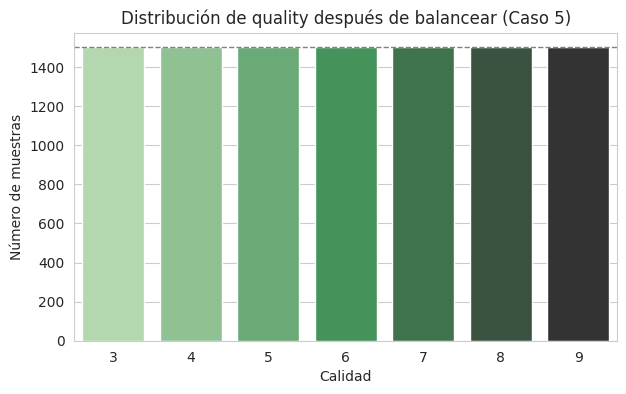

In [54]:
conteo_caso5 = y_caso5.value_counts().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=conteo_caso5.index, y=conteo_caso5.values, hue=conteo_caso5.index,
            palette='Greens_d', legend=False)
plt.title('Distribución de quality después de balancear (Caso 5)')
plt.xlabel('Calidad')
plt.ylabel('Número de muestras')
plt.axhline(n_objetivo, color='gray', linestyle='--', linewidth=1)
plt.show()

In [55]:
entrenar_y_evaluar(X_caso5, y_caso5, 'Caso 5: + Balanceado')

[Caso 5: + Balanceado] Accuracy: 0.4833  |  n_muestras: 10500  |  n_atributos: 10


0.48333333333333334

**Conclusión:** el accuracy cae notablemente de 0.5538 a 0.4833 al
balancear. Esto es esperable y no indica un peor modelo, sino una **métrica
más honesta**: en el Caso 4 (desbalanceado), el modelo podía acertar mucho
solo prediciendo casi siempre las clases mayoritarias (5, 6, 7), sin
necesariamente distinguir bien las clases minoritarias. Al balancear, el
modelo ya no puede apoyarse en esa ventaja estadística, y debe realmente
aprender a diferenciar las 7 clases con igual peso — lo cual es un problema
más difícil, especialmente para clases extremas (3, 9) que casi no tenían
datos reales y ahora dependen en gran parte de muestras sintéticas.
Este resultado sugiere que el accuracy del Caso 4 estaba, en parte,
inflado por el desbalanceo.

### Caso 6: Conjunto del Caso 5 aplicando PCA

Se aplica PCA (Análisis de Componentes Principales) sobre los atributos
de entrada del Caso 5 (balanceado), para reducir la dimensionalidad
conservando la mayor parte de la varianza. Se conserva el número de
componentes necesario para explicar al menos el 95% de la varianza total.

In [56]:
from sklearn.decomposition import PCA

# Se aplica PCA conservando el 95% de la varianza explicada
pca = PCA(n_components=0.95, random_state=42)
X_caso6 = pca.fit_transform(X_caso5)

print(f"Atributos originales: {X_caso5.shape[1]}")
print(f"Componentes principales retenidos: {X_caso6.shape[1]}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.4f}")

Atributos originales: 10
Componentes principales retenidos: 8
Varianza explicada acumulada: 0.9644


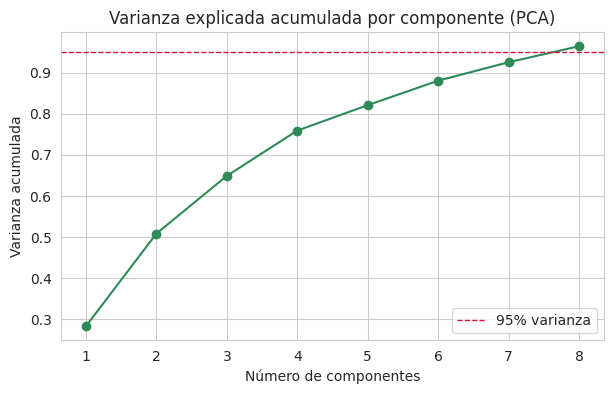

In [57]:
plt.figure(figsize=(7, 4))
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='seagreen')
plt.axhline(0.95, color='crimson', linestyle='--', linewidth=1, label='95% varianza')
plt.title('Varianza explicada acumulada por componente (PCA)')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.legend()
plt.show()

#### Visualización de PCA en 2D y 3D

Para inspeccionar visualmente la separabilidad de las clases, se proyectan
los datos del Caso 5 en 2 y 3 componentes principales (un PCA aparte, solo
para fines de visualización — el PCA usado para el entrenamiento del
Caso 6 conserva más componentes, los necesarios para el 95% de varianza).

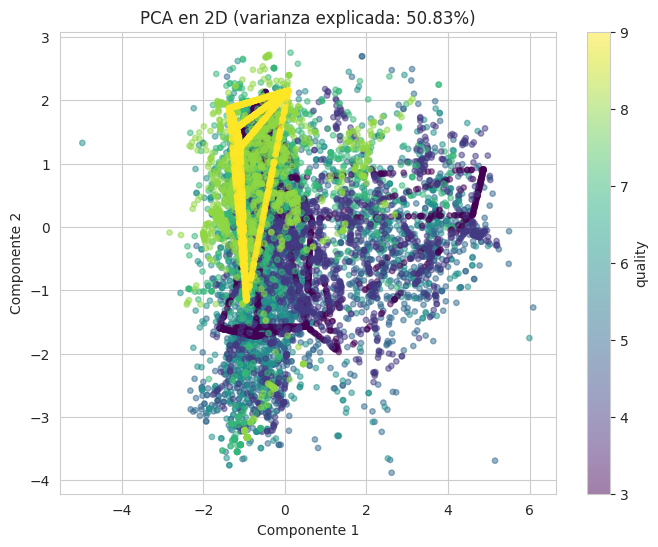

In [58]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_caso5)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_caso5, cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='quality')
plt.title(f'PCA en 2D (varianza explicada: {pca_2d.explained_variance_ratio_.sum():.2%})')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

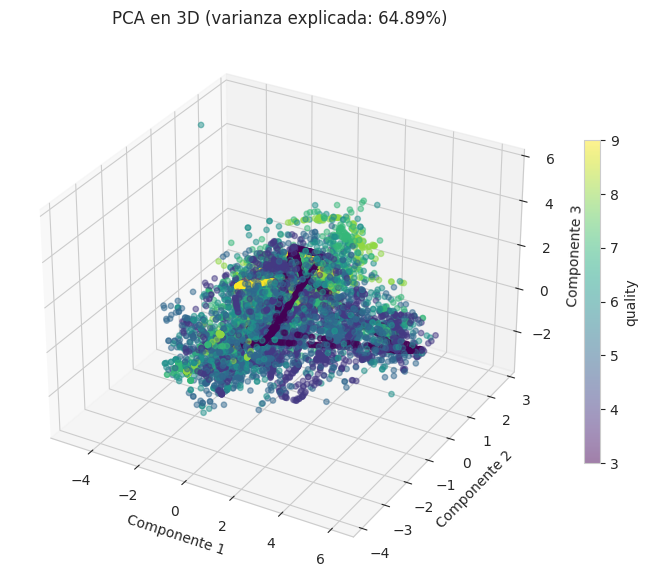

In [59]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_caso5)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=y_caso5, cmap='viridis', alpha=0.5, s=15)
fig.colorbar(scatter, label='quality', shrink=0.6)
ax.set_title(f'PCA en 3D (varianza explicada: {pca_3d.explained_variance_ratio_.sum():.2%})')
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_zlabel('Componente 3')
plt.show()

**Conclusión:** las proyecciones en 2D y 3D muestran una fuerte
superposición entre las clases de `quality`, lo cual explica la dificultad
del modelo para separarlas linealmente. Además, se observan patrones
geométricos artificiales (líneas y triángulos) correspondientes a las
clases con muy pocas muestras reales (`quality=3` y `9`), evidenciando
una limitación de SMOTE: con tan pocos puntos originales, los datos
sintéticos generados quedan restringidos a interpolaciones sobre las
mismas líneas, sin capturar la verdadera variabilidad de esas clases.

In [60]:
y_caso6 = y_caso5  # el objetivo no cambia, solo se transforman los atributos

entrenar_y_evaluar(X_caso6, y_caso6, 'Caso 6: + PCA')

[Caso 6: + PCA] Accuracy: 0.4524  |  n_muestras: 10500  |  n_atributos: 8


0.4523809523809524

**Conclusión:** al aplicar PCA sobre el Caso 5, el accuracy baja
levemente de 0.4833 a 0.4524, a pesar de reducir de 10 a 8 atributos
(conservando el 95% de la varianza). Esto es coherente con lo observado
en la Etapa 1 y en el Caso 4: como los atributos originales no tenían
alta redundancia entre sí, comprimirlos en menos componentes implica
perder algo de información útil para el modelo, sin una ganancia
compensatoria clara. Además, PCA no considera la variable objetivo al
construir los componentes, por lo que no necesariamente prioriza las
direcciones más útiles para distinguir las clases de `quality`.

## Tabla comparativa de resultados

In [61]:
tabla_resultados = pd.DataFrame(list(resultados.items()), columns=['Caso', 'Accuracy'])
tabla_resultados['Accuracy'] = tabla_resultados['Accuracy'].round(4)
tabla_resultados

,Caso,Accuracy
0,Caso 1: Original,0.5408
1,Caso 2: Sin faltantes,0.5408
2,Caso 3: Sin faltantes ni atípicos,0.5573
3,Caso 4: + Sin correlacionados,0.5538
4,Caso 5: + Balanceado,0.4833
5,Caso 6: + PCA,0.4524


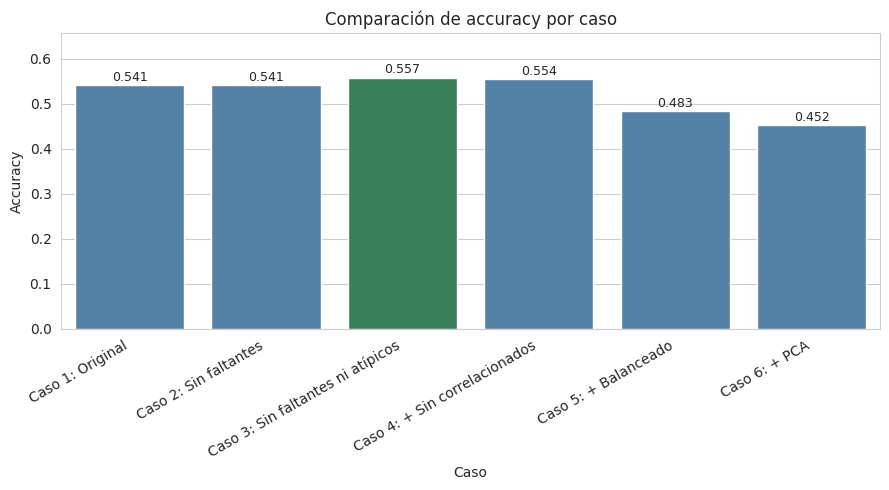

In [62]:
plt.figure(figsize=(9, 5))
colores_barras = ['seagreen' if v == tabla_resultados['Accuracy'].max() else 'steelblue'
                   for v in tabla_resultados['Accuracy']]
sns.barplot(x='Caso', y='Accuracy', data=tabla_resultados, hue='Caso',
            palette=colores_barras, legend=False)
plt.xticks(rotation=30, ha='right')
plt.title('Comparación de accuracy por caso')
plt.ylim(0, max(tabla_resultados['Accuracy']) + 0.1)
for i, v in enumerate(tabla_resultados['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Contexto: comparación con la literatura

El trabajo de Nebot, Mugica y Escobet (2015), [Modeling Wine Preferences
from Physicochemical Properties using Fuzzy Techniques](https://www.semanticscholar.org/paper/Modeling-Wine-Preferences-from-Physicochemical-Nebot-Mugica/e7c34d5b766df595105a9732355bb7dfb0f1dada), trabaja sobre
el mismo dataset (la porción de vino blanco) y el mismo atributo objetivo
`quality` (3-9), lo que permite contrastar algunos de nuestros hallazgos:

- **Dificultad del problema:** incluso los mejores modelos del estudio
  (SVM y un modelo de razonamiento inductivo difuso, FIR) obtienen
  accuracy de apenas ~63-64% permitiendo un margen de error de medio
  punto de calidad (T=0.5), y ~50-51% sin margen de tolerancia (T=0.25).
  Esto confirma que la baja accuracy obtenida en nuestros experimentos
  (0.45-0.56) es consistente con la dificultad reconocida en la literatura
  para este problema, más que un indicio de error en el pipeline.

- **Relevancia de atributos:** usando selección de características
  basada en entropía, los autores identifican `alcohol`, `fixed_acidity`,
  `free_sulfur_dioxide`, `residual_sugar` y `volatile_acidity` como las
  variables más relevantes, y señalan explícitamente que
  `total_sulfur_dioxide` es redundante frente a `free_sulfur_dioxide`.
  Esto **matiza nuestra decisión en el Caso 4**, donde eliminamos
  `free_sulfur_dioxide` y conservamos `total_sulfur_dioxide`: la
  literatura sugiere que hubiera sido más conveniente el criterio
  inverso. Nuestra elección se basó únicamente en el coeficiente de
  correlación de Pearson (que no distingue cuál de las dos variables es
  más informativa respecto al objetivo), mientras que el estudio citado
  usa una medida basada en relevancia predictiva.

- **Nota metodológica:** el estudio trata `quality` como una variable
  ordinal (con métricas como MAD y curvas REC que penalizan menos los
  errores "cercanos"), a diferencia de nuestro enfoque, que usa regresión
  logística multiclase sin considerar el orden entre categorías. Esto
  limita la comparabilidad directa de las métricas, pero confirma que el
  problema es intrínsecamente difícil de resolver con alta precisión.

## Conclusión general

**Tabla de resultados:**

| Caso | Accuracy | Cambio |
|---|---|---|
| 1. Original | 0.5408 | — |
| 2. Sin faltantes | 0.5408 | Sin efecto (no había faltantes) |
| 3. Sin faltantes ni atípicos | 0.5573 | +0.0165 |
| 4. + Sin correlacionados | 0.5538 | -0.0035 |
| 5. + Balanceado | 0.4833 | -0.0705 |
| 6. + PCA | 0.4524 | -0.0309 |

**¿Qué actividades tuvieron más impacto?**

- **Eliminar datos atípicos** fue la única actividad que mejoró el
  accuracy (+1.65 puntos), aunque con la salvedad de que los atípicos
  se concentraban en las clases minoritarias, por lo que esta mejora
  también reduce la representación de esas clases.
- **Eliminar atributos correlacionados** tuvo un impacto marginal
  (-0.35 puntos), coherente con que ningún par de atributos superaba
  |r|=0.75 en la Etapa 1.
- **Balancear las clases** fue la actividad de mayor impacto en
  magnitud, pero en sentido negativo para el accuracy global (-7.05
  puntos). Esto no debe interpretarse como un retroceso: el accuracy
  del Caso 4 estaba inflado por el desbalanceo, ya que el modelo podía
  acertar mucho apoyándose solo en las clases mayoritarias. El Caso 5
  ofrece una medida más honesta de la capacidad real del modelo para
  distinguir las 7 clases.
- **Aplicar PCA** también redujo el accuracy (-3.09 puntos), sin
  justificarse por una alta redundancia previa entre atributos (como se
  confirmó en la Etapa 1 y en el paper de referencia).

**¿Qué versión obtiene mejores resultados?**

En términos de accuracy puro, el **Caso 3** (sin faltantes ni atípicos)
es el mejor (0.5573). Sin embargo, considerando que el objetivo real es
un modelo útil para las 7 clases —incluidas las minoritarias, que son
las de mayor interés práctico para el productor (vinos excelentes o
defectuosos)—, el **Caso 5** (balanceado) es la versión más honesta y
recomendable, ya que su accuracy más bajo refleja una evaluación
genuina sobre todas las clases, en lugar de un desempeño inflado por
la mayoría estadística de las clases 5 y 6.